# LIBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lib.graph import plot_data, draw_vthresh
from lib.ml_functions import sigmoid, compute_cost_logistic, compute_gradient_logistic
from lib.ml_functions import gradient_descent_logistic, predict_logistic, zscore_normalize_features
from lib.data import load_text_data
plt.style.use('./lib/deeplearning.mplstyle')


%matplotlib inline

## BACKEND

### Case 1: Límite y umbral de clasificación

In [2]:
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1,1) 

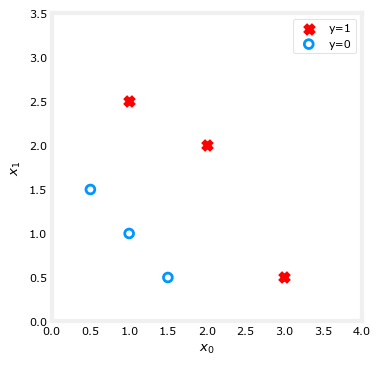

In [3]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
plot_data(X, y, ax)

ax.axis([0, 4, 0, 3.5])
ax.set_ylabel('$x_1$')
ax.set_xlabel('$x_0$')
plt.show()

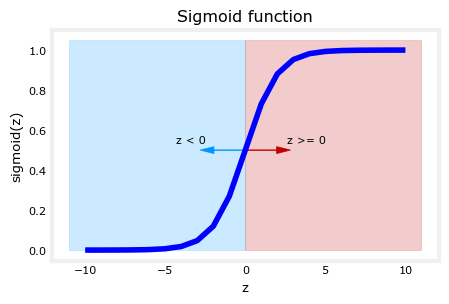

In [4]:
# Plot sigmoid(z) over a range of values from -10 to 10
z = np.arange(-10, 11)

fig,ax = plt.subplots(1, 1, figsize = (5, 3))
# Plot z vs sigmoid(z)
ax.plot(z, sigmoid(z), c = 'b')

ax.set_title('Sigmoid function')
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')
draw_vthresh(ax, 0)

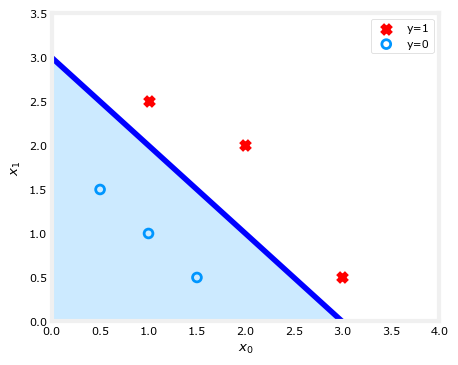

In [5]:
# Choose values between 0 and 6
x0 = np.arange(0, 6)

x1 = 3 - x0
fig,ax = plt.subplots(1, 1, figsize = (5, 4))
# Plot the decision boundary
ax.plot(x0,x1, c = 'b')
ax.axis([0, 4, 0, 3.5])

# Fill the region below the line
ax.fill_between(x0, x1, alpha = 0.2)

# Plot the original data
plot_data(X, y, ax)
ax.set_ylabel(r'$x_1$')
ax.set_xlabel(r'$x_0$')
plt.show()

### Case 2: Gradiente y predicción sin estandarización

In [6]:
# load dataset
X_train, y_train = load_text_data(file_name = '../../data/ex2data1.txt', delimiter = ',', until_col = 2, skip_rows = 0)

In [7]:
print(f'First five elements in X_train are: {X_train[:5]}')
print(f'Type of X_train: {type(X_train)}')

First five elements in X_train are: [[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]
Type of X_train: <class 'numpy.ndarray'>


In [8]:
print(f'First five elements in y_train are: {y_train[:5]}')
print(f'Type of y_train: {type(y_train)}')

First five elements in y_train are: [0. 0. 0. 1. 1.]
Type of y_train: <class 'numpy.ndarray'>


In [9]:
print (f'The shape of X_train is: {X_train.shape}')
print (f'The shape of y_train is: {y_train.shape}')
print (f'We have m = {(len(y_train))} training examples')

The shape of X_train is: (100, 2)
The shape of y_train is: (100,)
We have m = 100 training examples


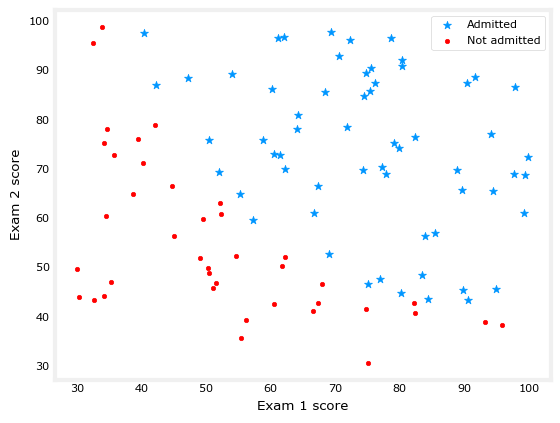

In [10]:
pos , neg = (y_train == 1).reshape(100, 1), (y_train == 0).reshape(100, 1)
plt.scatter(X_train[pos[:,0], 0],X_train[pos[:,0], 1], marker = '*')
plt.scatter(X_train[neg[:,0], 0],X_train[neg[:,0], 1], c = 'r', marker = 'o', s = 10)
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend(['Admitted','Not admitted'], loc = 0)

#### Sigmoid function

In [11]:
# Note: You can edit this value
value = 0

print (f'sigmoid({value}) = {sigmoid(value)}')

sigmoid(0) = 0.5


In [12]:
print (f'sigmoid([ -1, 0, 1, 2]) =  {str(sigmoid(np.array([-1, 0, 1, 2])))}')

sigmoid([ -1, 0, 1, 2]) =  [0.26894142 0.5        0.73105858 0.88079708]


#### Cost function for logistic regression

In [13]:
m, n = X_train.shape

# Compute and display cost with w and b initialized to zeros
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost_logistic(X_train, y_train, initial_w, initial_b)
print(f'Cost at initial w and b (zeros): {cost: .3f}')

Cost at initial w and b (zeros):  0.693


In [14]:
# Compute and display cost with non-zero w and b
test_w = np.array([0.2, 0.2])
test_b = -24.
cost = compute_cost_logistic(X_train, y_train, test_w, test_b)

print(f'Cost at test w and b (non-zeros): {cost: .3f}')



Cost at test w and b (non-zeros):  0.218


#### Gradient for logistic regression

In [15]:
# Compute and display gradient with w and b initialized to zeros
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient_logistic(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w and b (zeros): {dj_db}' )
print(f'dj_dw at initial w and b (zeros): {dj_dw.tolist()}' )

dj_db at initial w and b (zeros): -0.1
dj_dw at initial w and b (zeros): [-12.009216589291151, -11.262842205513593]


In [16]:
# Compute and display cost and gradient with non-zero w and b
test_w = np.array([ 0.2, -0.5])
test_b = -24
dj_db, dj_dw = compute_gradient_logistic(X_train, y_train, test_w, test_b)

print(f'dj_db at initial w and b: {dj_db}' )
print(f'dj_dw at initial w and b: {dj_dw.tolist()}' )

dj_db at initial w and b: -0.5999999999991071
dj_dw at initial w and b: [-44.831353617873795, -44.373841249539794]


#### Learning parameters using gradient descent 

In [17]:
np.random.seed(1)
initial_w = 0.01 * (np.random.rand(2) - 0.5)
initial_b = -8

# Some gradient descent settings
iterations = 10000
alpha = 0.001

w, b, J_history, p_history = gradient_descent_logistic(X_train ,y_train, initial_w, initial_b, alpha, iterations)

Iteration         0: Cost  0.96  w: ['0.04', '0.05'], b:-8.00 dj_dw: ['-44.81', '-44.35'], dj_db: -0.60
Iteration      1000: Cost  0.31  w: ['0.07', '0.06'], b:-8.02 dj_dw: ['-0.00', '-0.00'], dj_db:  0.02
Iteration      2000: Cost  0.30  w: ['0.07', '0.06'], b:-8.04 dj_dw: ['-0.00', '-0.00'], dj_db:  0.02
Iteration      3000: Cost  0.30  w: ['0.07', '0.06'], b:-8.06 dj_dw: ['-0.00', '-0.00'], dj_db:  0.02
Iteration      4000: Cost  0.30  w: ['0.07', '0.06'], b:-8.08 dj_dw: ['-0.00', '-0.00'], dj_db:  0.02
Iteration      5000: Cost  0.30  w: ['0.07', '0.06'], b:-8.09 dj_dw: ['-0.00', '-0.00'], dj_db:  0.02
Iteration      6000: Cost  0.30  w: ['0.07', '0.06'], b:-8.11 dj_dw: ['-0.00', '-0.00'], dj_db:  0.02
Iteration      7000: Cost  0.30  w: ['0.07', '0.06'], b:-8.13 dj_dw: ['-0.00', '-0.00'], dj_db:  0.02
Iteration      8000: Cost  0.30  w: ['0.07', '0.06'], b:-8.15 dj_dw: ['-0.00', '-0.00'], dj_db:  0.02
Iteration      9000: Cost  0.30  w: ['0.07', '0.06'], b:-8.17 dj_dw: ['-0.00', '

Text(0.5, 1.0, 'Cost function using Gradient Descent')

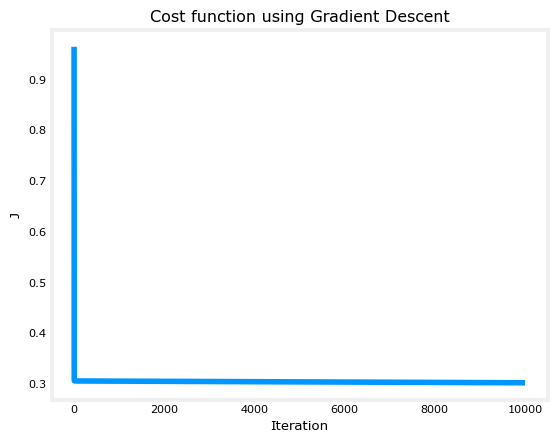

In [18]:
plt.plot(J_history)
plt.xlabel('Iteration')
plt.ylabel('J')
plt.title('Cost function using Gradient Descent')

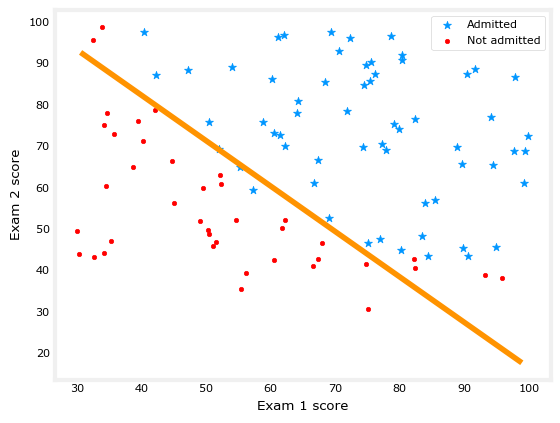

In [19]:
plt.scatter(X_train[pos[:,0],0],X_train[pos[:,0],1], marker = '*')
plt.scatter(X_train[neg[:,0],0],X_train[neg[:,0],1], c = 'r', marker = 'o', s = 10)

x_value = np.array([np.min(X_train[:,1]), np.max(X_train[:,1])])
y_value = -(b + w[0] * x_value)/w[1]
plt.plot(x_value,y_value, '#FF9300')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend(['Admitted','Not admitted'], loc = 0)

#### Predictions

In [20]:
# Test your predict code
np.random.seed(1)
tmp_w = np.random.randn(2)
tmp_b = 0.3    
tmp_X = np.random.randn(4, 2) - 0.5

tmp_p = predict_logistic(tmp_X, tmp_w, tmp_b)
print(f'Output of predict: shape {tmp_p.shape}, value {tmp_p}')

Output of predict: shape (4,), value [0. 1. 1. 1.]


In [21]:
#Compute accuracy on our training set
p = predict_logistic(X_train, w, b)
# print(f'Train Accuracy: {(np.mean(p == y_train) * 100): .2f}%')
p


array([0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1.,
       0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1.,
       0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1.,
       1., 0., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.])

In [22]:
x_test = np.array([55, 85])
# x_test = (x_test - X_mean)/X_std
prob = sigmoid(np.dot(x_test, w) + b)
print(f'For a student with scores {x_test[0]} and {x_test[1]}, we predict an admission probability of: {(prob * 100):.2f}%')

For a student with scores 55 and 85, we predict an admission probability of: 77.57%


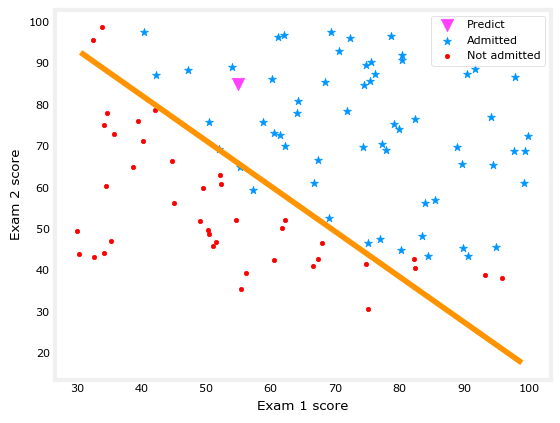

In [23]:
plt.scatter(x_test[0], x_test[1], c = '#FF40FF', marker='v', s = 80, label='(45, 85)')
plt.scatter(X_train[pos[:,0],0],X_train[pos[:,0],1], marker = '*')
plt.scatter(X_train[neg[:,0],0],X_train[neg[:,0],1], c = 'r', marker = 'o', s = 10)

x_value = np.array([np.min(X_train[:,1]), np.max(X_train[:,1])])
y_value = -(b + w[0] * x_value)/w[1]
plt.plot(x_value,y_value, '#FF9300')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend(['Predict', 'Admitted','Not admitted'],loc = 0)



### Case 3: Gradiente y predicción con estandarización

In [24]:
X_train_normalized, X_mean, X_std = zscore_normalize_features(X_train)

In [25]:
print('First five elements in X_train_normalized are:\n', X_train_normalized[:5])
print('Type of X_train_normalized:',type(X_train_normalized))

First five elements in X_train_normalized are:
 [[-1.60224763  0.63834112]
 [-1.82625564 -1.2075414 ]
 [-1.53903969  0.3612943 ]
 [-0.28210129  1.0863683 ]
 [ 0.69152826  0.49337794]]
Type of X_train_normalized: <class 'numpy.ndarray'>


In [26]:
print(f'First five elements in y_train are: {y_train[:5]}')
print(f'Type of y_train: {type(y_train)}')

First five elements in y_train are: [0. 0. 0. 1. 1.]
Type of y_train: <class 'numpy.ndarray'>


In [27]:
print (f'The shape of X_train_normalized is: {X_train_normalized.shape}')
print (f'The shape of y_train is: {y_train.shape}')
print (f'We have m = {(len(y_train))} training examples')

The shape of X_train_normalized is: (100, 2)
The shape of y_train is: (100,)
We have m = 100 training examples


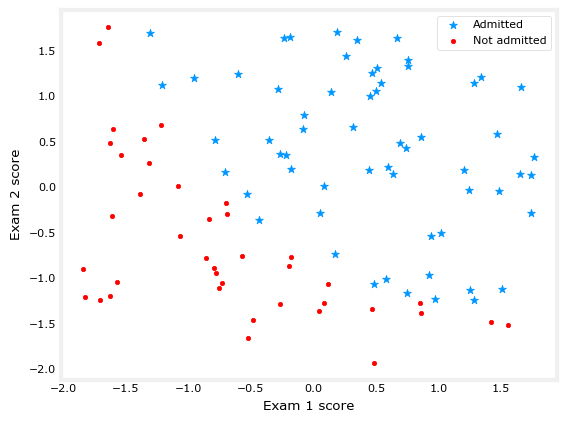

In [28]:
pos , neg = (y_train == 1).reshape(100, 1), (y_train == 0).reshape(100, 1)
plt.scatter(X_train_normalized[pos[:,0], 0],X_train_normalized[pos[:,0], 1], marker = '*')
plt.scatter(X_train_normalized[neg[:,0], 0],X_train_normalized[neg[:,0], 1], c = 'r', marker = 'o', s = 10)
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend(['Admitted','Not admitted'], loc = 0)

#### Cost function for logistic regression

In [29]:
m, n = X_train_normalized.shape

# Compute and display cost with w and b initialized to zeros
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost_logistic(X_train_normalized, y_train, initial_w, initial_b)
print(f'Cost at initial w and b (zeros): {cost :.3f}')

Cost at initial w and b (zeros): 0.693


#### Gradient for logistic regression

In [30]:
# Compute and display gradient with w and b initialized to zeros
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient_logistic(X_train_normalized, y_train, initial_w, initial_b)
print(f'dj_db at initial w and b (zeros): {dj_db}' )
print(f'dj_dw at initial w and b (zeros): {dj_dw.tolist()}' )

dj_db at initial w and b (zeros): -0.1
dj_dw at initial w and b (zeros): [-0.2812291353307309, -0.2509861459349201]


In [31]:
# Compute and display cost and gradient with non-zero w and b
test_w = np.array([ 0.2, -0.5])
test_b = -24
dj_db, dj_dw = compute_gradient_logistic(X_train_normalized, y_train, test_w, test_b)

print(f'dj_db at initial w and b: {dj_db}' )
print(f'dj_dw at initial w and b: {dj_dw.tolist()}' )

dj_db at initial w and b: -0.5999999999564044
dj_dw at initial w and b: [-0.2812291353213714, -0.25098614595575275]


#### Learning parameters using gradient descent 

In [32]:
np.random.seed(1)
initial_w = 0.01 * (np.random.rand(2) - 0.5)
initial_b = -8

# Some gradient descent settings
iterations = 10000
alpha = 0.01

w, b, J_history, p_history = gradient_descent_logistic(X_train_normalized ,y_train, initial_w, initial_b, alpha, iterations)

Iteration         0: Cost  4.79  w: ['0.00', '0.00'], b:-7.99 dj_dw: ['-0.28', '-0.25'], dj_db: -0.60
Iteration      1000: Cost  0.91  w: ['2.25', '1.97'], b:-2.65 dj_dw: ['-0.09', '-0.06'], dj_db: -0.36
Iteration      2000: Cost  0.32  w: ['2.53', '2.18'], b:-0.36 dj_dw: ['-0.00', '-0.01'], dj_db: -0.14
Iteration      3000: Cost  0.24  w: ['2.57', '2.28'], b: 0.54 dj_dw: ['-0.01', '-0.01'], dj_db: -0.05
Iteration      4000: Cost  0.22  w: ['2.64', '2.39'], b: 0.89 dj_dw: ['-0.01', '-0.01'], dj_db: -0.02
Iteration      5000: Cost  0.22  w: ['2.74', '2.50'], b: 1.05 dj_dw: ['-0.01', '-0.01'], dj_db: -0.01
Iteration      6000: Cost  0.21  w: ['2.84', '2.61'], b: 1.15 dj_dw: ['-0.01', '-0.01'], dj_db: -0.01
Iteration      7000: Cost  0.21  w: ['2.94', '2.70'], b: 1.21 dj_dw: ['-0.01', '-0.01'], dj_db: -0.01
Iteration      8000: Cost  0.21  w: ['3.02', '2.78'], b: 1.25 dj_dw: ['-0.01', '-0.01'], dj_db: -0.00
Iteration      9000: Cost  0.21  w: ['3.10', '2.86'], b: 1.29 dj_dw: ['-0.01', '-0

Text(0.5, 1.0, 'Cost function using Gradient Descent')

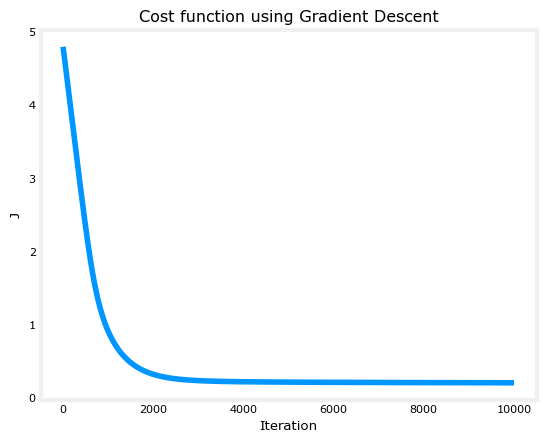

In [33]:
plt.plot(J_history)
plt.xlabel('Iteration')
plt.ylabel('J')
plt.title('Cost function using Gradient Descent')

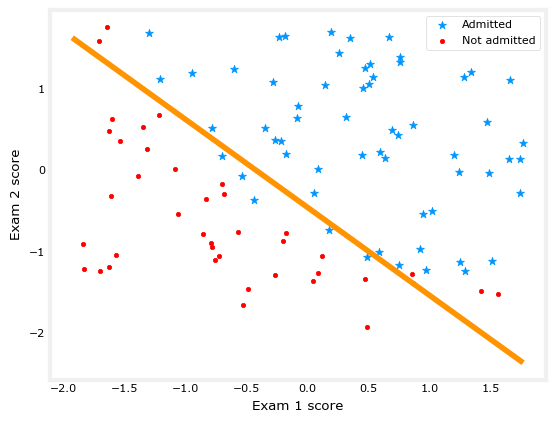

In [34]:
plt.scatter(X_train_normalized[pos[:,0],0],X_train_normalized[pos[:,0], 1], marker = '*')
plt.scatter(X_train_normalized[neg[:,0],0],X_train_normalized[neg[:,0], 1], c = 'r', marker = 'o', s = 10)

x_value = np.array([np.min(X_train_normalized[:, 1]), np.max(X_train_normalized[:, 1])])
y_value = -(b + w[0] * x_value)/w[1]
plt.plot(x_value,y_value, '#FF9300')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend(['Admitted','Not admitted'], loc = 0)

#### Predictions

In [35]:
#Compute accuracy on our training set
p = predict_logistic(X_train_normalized, w, b)
print(f'Train Accuracy: {(np.mean(p == y_train) * 100): .2f}%')

Train Accuracy:  89.00%


In [36]:
x_test = np.array([55, 85])
x_test = (x_test - X_mean)/X_std
prob = sigmoid(np.dot(x_test, w) + b)
print(f'For a student with scores {x_test[0]: .2f} and {x_test[1]: .2f}, we predict an admission probability of: {(prob * 100):.2f}%')

For a student with scores -0.55 and  1.02, we predict an admission probability of: 92.80%


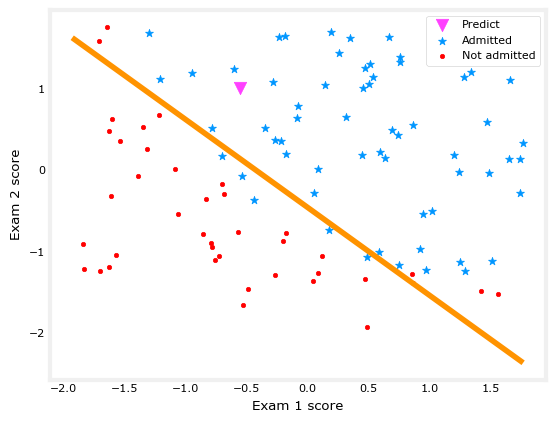

In [37]:
plt.scatter(x_test[0], x_test[1], c = '#FF40FF', marker='v', s = 80, label='(45, 85)')
plt.scatter(X_train_normalized[pos[:,0],0],X_train_normalized[pos[:,0],1], marker = '*')
plt.scatter(X_train_normalized[neg[:,0],0],X_train_normalized[neg[:,0],1], c = 'r', marker = 'o', s = 10)

x_value = np.array([np.min(X_train_normalized[:,1]), np.max(X_train_normalized[:,1])])
y_value = -(b + w[0] * x_value)/w[1]
plt.plot(x_value,y_value, '#FF9300')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend(['Predict', 'Admitted','Not admitted'],loc = 0)
